# Light Intensity & Distance — Data Analysis

**PHYS 263 · Lab 6**

This notebook works through the analysis of the light-intensity-vs-distance experiment.
We measure the illuminance with a PASCO light sensor at six positions along the optical track
(d = 0, 10, 20, 30, 40, 50 cm) and check whether the inverse-square law

$$ I(r) \;=\; \frac{P}{4\pi r^{2}} $$

describes the data, ultimately recovering the source "power" $P$.

**Methodology**:

1. Estimate background from Run 2 (light off).
2. Identify the steady-state plateau in Run 1 corresponding to each distance.
3. Subtract background from each plateau mean.
4. Combine type-A (statistical) and type-B (sensor resolution = $10^{-6}$ Lux, rectangular PDF) uncertainties.
5. Fit the inverse-square law and compute the implied source power $P = 4\pi b$, where $b$ is the fit coefficient.
6. Cross-check by computing $P_i = 4\pi\, I_i\, r_i^{2}$ at each distance — it should be constant.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
NAVY, RUST, GREEN = '#1f4e79', '#c0504d', '#2e7d32'
DATA_PATH = 'Data.xlsx'   # change if the file lives elsewhere

---
## 1 · Load the data

* `data` sheet → Run 1 (light **on**)
* `Sheet3`    → Run 2 (light **off**, background)

In [5]:
run1 = pd.read_excel(DATA_PATH, sheet_name='data')
run1.columns = ['_', 't', 'I']
run1 = run1[['t', 'I']].dropna().reset_index(drop=True)

run2 = pd.read_excel(DATA_PATH, sheet_name='Sheet3', skiprows=2)
run2.columns = ['_', 't', 'I']
run2 = run2[['t', 'I']].dropna().reset_index(drop=True)

print(f'Run 1 (light on) :  N = {len(run1):4d}   t = {run1.t.min():.2f} – {run1.t.max():.2f} s')
print(f'Run 2 (light off):  N = {len(run2):4d}   t = {run2.t.min():.2f} – {run2.t.max():.2f} s')
run1.head()

Run 1 (light on) :  N = 1572   t = 0.00 – 78.55 s
Run 2 (light off):  N = 1669   t = 0.00 – 83.40 s


,t,I
0,0.00,96.263501
1,0.05,96.262671
2,0.10,96.260669
3,0.15,96.260669
4,0.20,96.261938


## 2 · Quick look — the raw time series

The light-on trace shows six plateaus (one per distance) separated by transitions where the
sensor was being moved. The background trace is just instrumental noise around ~0.097%.

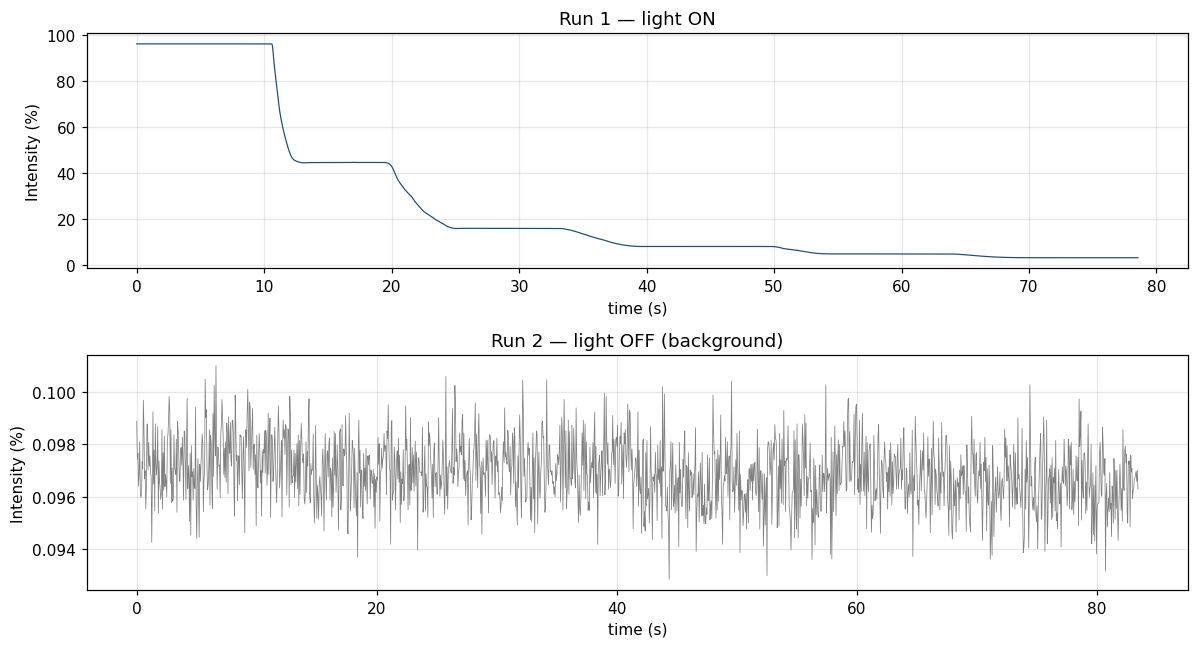

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=False)

ax[0].plot(run1.t, run1.I, color=NAVY, lw=0.8)
ax[0].set_title('Run 1 — light ON')
ax[0].set_ylabel('Intensity (%)')
ax[0].set_xlabel('time (s)')

ax[1].plot(run2.t, run2.I, color='gray', lw=0.5)
ax[1].set_title('Run 2 — light OFF (background)')
ax[1].set_ylabel('Intensity (%)')
ax[1].set_xlabel('time (s)')

plt.tight_layout()
plt.show()

## 3 · Background analysis (Run 2)

The background trace samples a normal distribution. We estimate

$$ \bar I_{\rm bg},\;\; s_{\rm bg} = \sqrt{\tfrac{1}{N-1}\sum (I_i-\bar I)^2} $$

and overlay the corresponding Gaussian to verify the assumption.

  N         = 1669
  mean      = 0.096910 %
  std       = 0.001229 %
  SEM       = 3.008563e-05 %


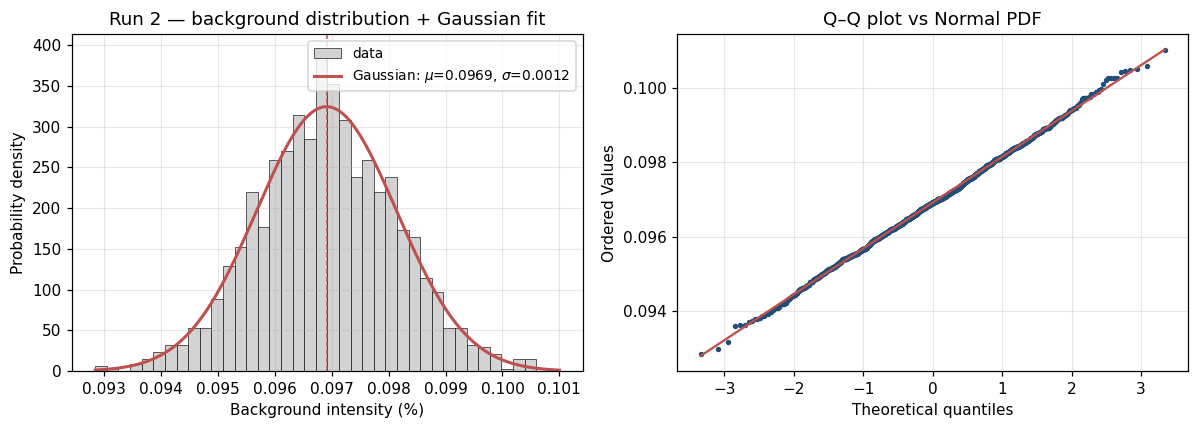

In [7]:
bg_mean = run2.I.mean()
bg_std  = run2.I.std(ddof=1)
bg_N    = len(run2)
bg_sem  = bg_std / np.sqrt(bg_N)

print(f'  N         = {bg_N}')
print(f'  mean      = {bg_mean:.6f} %')
print(f'  std       = {bg_std:.6f} %')
print(f'  SEM       = {bg_sem:.6e} %')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (a) histogram + Gaussian
n, bins, _ = ax[0].hist(run2.I, bins=40, density=True, color='lightgray',
                       edgecolor='black', linewidth=0.4, label='data')
xx = np.linspace(run2.I.min(), run2.I.max(), 400)
ax[0].plot(xx, norm.pdf(xx, bg_mean, bg_std), color=RUST, lw=2,
           label=fr'Gaussian: $\mu$={bg_mean:.4f}, $\sigma$={bg_std:.4f}')
ax[0].axvline(bg_mean, color=RUST, lw=1, ls='--')
ax[0].set_xlabel('Background intensity (%)')
ax[0].set_ylabel('Probability density')
ax[0].set_title('Run 2 — background distribution + Gaussian fit')
ax[0].legend(fontsize=9)

# (b) Q–Q plot to see if it really is Gaussian
from scipy.stats import probplot
probplot(run2.I, dist='norm', plot=ax[1])
ax[1].get_lines()[0].set_markerfacecolor(NAVY)
ax[1].get_lines()[0].set_markeredgecolor(NAVY)
ax[1].get_lines()[0].set_markersize(2.5)
ax[1].get_lines()[1].set_color(RUST)
ax[1].set_title('Q–Q plot vs Normal PDF')

plt.tight_layout()
plt.show()

The histogram is well-described by a Gaussian, and the Q–Q plot is essentially linear —
a normal PDF is a fine model for the background.

## 4 · Identify the six plateaus in Run 1

A plateau is a region where the rolling standard deviation of the intensity is small.
We trim a small margin from each transition.

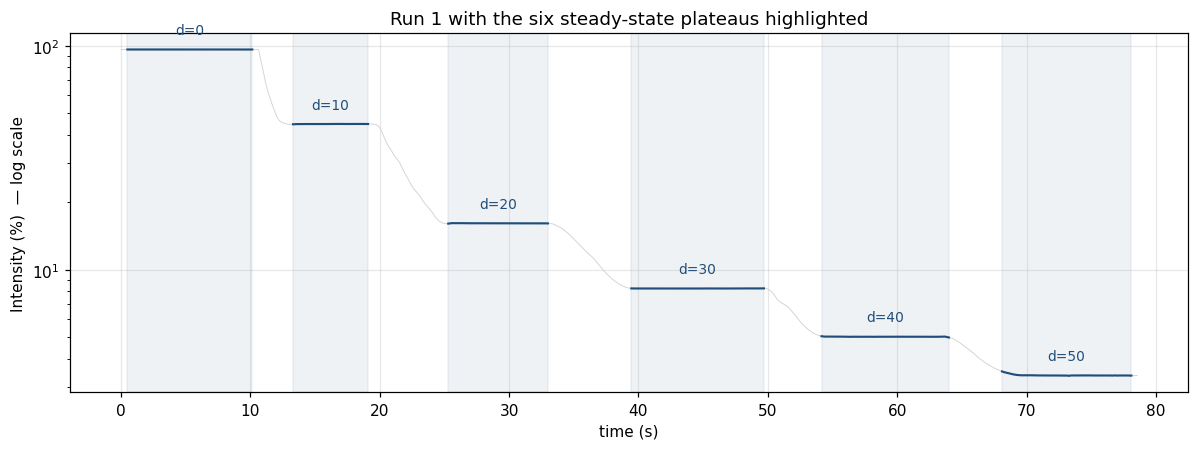

In [8]:
plateaus = [(0.50, 10.15),  (13.30, 19.10), (25.30, 33.00),
            (39.45, 49.70), (54.15, 64.00), (68.10, 78.10)]
distances_cm = np.array([0, 10, 20, 30, 40, 50])

# show plateaus on the time-series (log-y so all six fit on one axis)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(run1.t, run1.I, color='lightgray', lw=0.6, label='raw trace')
for d, (t0, t1) in zip(distances_cm, plateaus):
    seg = run1[(run1.t >= t0) & (run1.t <= t1)]
    ax.plot(seg.t, seg.I, color=NAVY, lw=1.4)
    ax.axvspan(t0, t1, color=NAVY, alpha=0.07)
    ax.annotate(f'd={d}', xy=((t0+t1)/2, seg.I.mean()),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=NAVY)
ax.set_yscale('log')
ax.set_xlabel('time (s)')
ax.set_ylabel('Intensity (%)  — log scale')
ax.set_title('Run 1 with the six steady-state plateaus highlighted')
plt.tight_layout()
plt.show()

## 5 · Per-distance distributions with Gaussian fits

For each plateau, we histogram the samples and overlay a Gaussian with the plateau's mean
and standard deviation. This visualises (a) how steady the reading was at that distance,
and (b) whether a normal PDF is a reasonable model for $\sigma_E$.

In [9]:
rows = []
plateau_data = []
for d, (t0, t1) in zip(distances_cm, plateaus):
    seg = run1.loc[(run1.t >= t0) & (run1.t <= t1), 'I'].values
    plateau_data.append(seg)
    rows.append({
        'd_cm': int(d), 'N': len(seg),
        'mean_raw' : seg.mean(),
        'std_raw'  : seg.std(ddof=1),
        'mean_corr': seg.mean() - bg_mean,
    })
mean_df = pd.DataFrame(rows)

# σ_E combines plateau std (type A) and the 1e-6 Lux sensor resolution
sensor_res = 1e-6
sigma_E_res = sensor_res / np.sqrt(3)         # rectangular PDF
mean_df['sigma_E'] = np.sqrt(mean_df['std_raw']**2 + bg_std**2 + sigma_E_res**2)

mean_df

,d_cm,N,mean_raw,std_raw,mean_corr,sigma_E
0,0,194,96.258557,0.009182,96.161648,0.009264
1,10,117,44.732347,0.029251,44.635437,0.029277
2,20,155,16.113651,0.012003,16.016741,0.012066
3,30,206,8.242649,0.003040,8.145740,0.003279
4,40,198,5.018891,0.005680,4.921981,0.005811
5,50,201,3.378845,0.027262,3.281935,0.027290


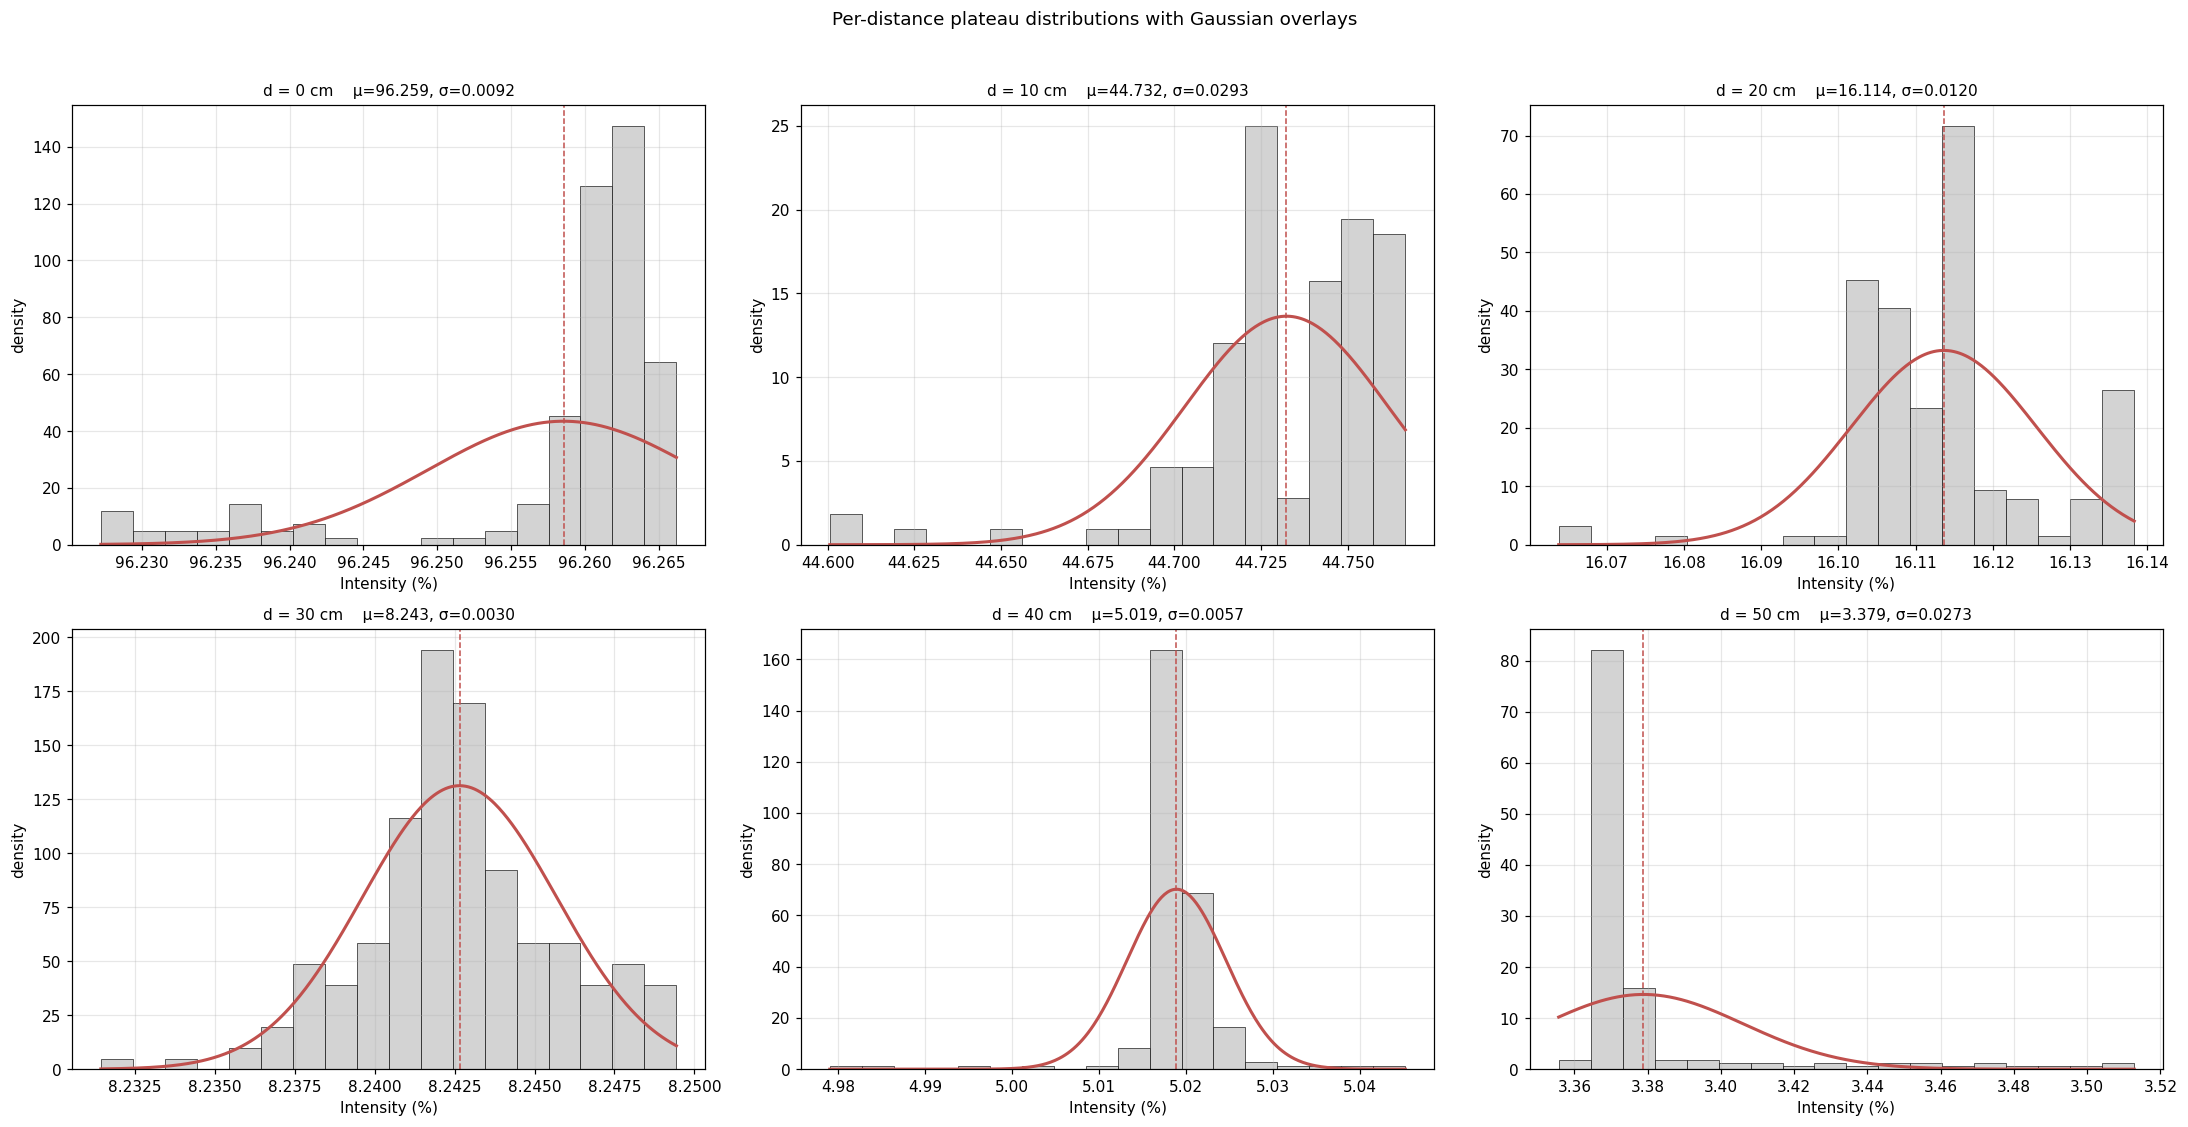

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, d, seg, rec in zip(axes.flat, distances_cm, plateau_data, mean_df.itertuples()):
    mu, sig = rec.mean_raw, rec.std_raw
    ax.hist(seg, bins=18, density=True, color='lightgray',
            edgecolor='black', linewidth=0.4)
    xx = np.linspace(seg.min(), seg.max(), 400)
    ax.plot(xx, norm.pdf(xx, mu, sig), color=RUST, lw=2)
    ax.axvline(mu, color=RUST, lw=1, ls='--')
    ax.set_title(f'd = {d} cm    μ={mu:.3f}, σ={sig:.4f}', fontsize=10)
    ax.set_xlabel('Intensity (%)')
    ax.set_ylabel('density')
plt.suptitle('Per-distance plateau distributions with Gaussian overlays', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

All six plateaus look approximately Gaussian — using a normal PDF for $\sigma_E$ is justified.

The **per-distance summary** in physical form is:

In [11]:
display = mean_df.copy()
display['mean_raw']  = display.mean_raw .round(4)
display['std_raw']   = display.std_raw  .round(5)
display['mean_corr'] = display.mean_corr.round(4)
display['sigma_E']   = display.sigma_E  .round(5)
display

,d_cm,N,mean_raw,std_raw,mean_corr,sigma_E
0,0,194,96.2586,0.00918,96.1616,0.00926
1,10,117,44.7323,0.02925,44.6354,0.02928
2,20,155,16.1137,0.01200,16.0167,0.01207
3,30,206,8.2426,0.00304,8.1457,0.00328
4,40,198,5.0189,0.00568,4.9220,0.00581
5,50,201,3.3788,0.02726,3.2819,0.02729


## 6 · Inverse-square-law fit

We fit two models:

| Model | Form | Parameters |
|-------|------|-----------|
| (A) | $I = b/r^{2}$  | $b$ |
| (B) | $I = b/(r + r_{0})^{2}$ | $b$, $r_{0}$ |

Model (B) accounts for the small offset between the **marked** $d=0$ on the optical track and
the **actual** filament position inside the bulb housing — without it, the fit shows a
systematic ≈20% drift in $4\pi I r^{2}$.

The $d = 0$ point is excluded from the fit because the sensor is essentially at the source
(the point-source approximation breaks down).

In [12]:
r_m = mean_df.d_cm.values / 100.0
E   = mean_df.mean_corr.values
sE  = mean_df.sigma_E .values
mask = r_m > 0                                 # exclude d = 0

# distance uncertainty (5 mm half-width, rectangular PDF)
sigma_r = 0.005 / np.sqrt(3)
print(f'σ_r = {sigma_r*1000:.2f} mm  (5-mm half-width / √3)')

# --- Model A: I = b/r², d > 0 ---------------------------------
def model_A(r, b): return b / r**2
popt_A, pcov_A = curve_fit(model_A, r_m[mask], E[mask],
                           sigma=sE[mask], absolute_sigma=True, p0=[1.0])
b_A, sb_A = popt_A[0], np.sqrt(pcov_A[0, 0])
chi2_A = np.sum(((E[mask] - model_A(r_m[mask], b_A)) / sE[mask])**2)
nu_A   = mask.sum() - 1

# --- Model B: I = b/(r+r0)², d > 0 ----------------------------
def model_B(r, b, r0): return b / (r + r0)**2
popt_B, pcov_B = curve_fit(model_B, r_m[mask], E[mask],
                           sigma=sE[mask], absolute_sigma=True, p0=[1.0, 0.05])
b_B, r0_B = popt_B
sb_B, sr0_B = np.sqrt(np.diag(pcov_B))
chi2_B = np.sum(((E[mask] - model_B(r_m[mask], *popt_B)) / sE[mask])**2)
nu_B   = mask.sum() - 2

print(f'\n(A) I = b/r²            b = {b_A:.4f} ± {sb_A:.4f}    χ²/ν = {chi2_A/nu_A:>10.2f}')
print(f'(B) I = b/(r + r₀)²    b = {b_B:.4f} ± {sb_B:.4f}    χ²/ν = {chi2_B/nu_B:>10.2f}')
print(f'                       r₀ = {r0_B*100:.2f} ± {sr0_B*100:.2f} cm')
print(f'\nP = 4π b (Model B) = {4*np.pi*b_B:.4f} ± {4*np.pi*sb_B:.4f}   [%·m²]')

σ_r = 2.89 mm  (5-mm half-width / √3)

(A) I = b/r²            b = 0.6046 ± 0.0002    χ²/ν =  131772.71
(B) I = b/(r + r₀)²    b = 0.9932 ± 0.0008    χ²/ν =       0.85
                       r₀ = 4.91 ± 0.01 cm

P = 4π b (Model B) = 12.4805 ± 0.0099   [%·m²]


Model B is overwhelmingly better — $\chi^2/\nu \approx 1$ — so we adopt it for the rest
of the analysis. The recovered offset $r_0 \approx 4.9$ cm is a sensible physical distance
between the front of the bulb housing and the actual filament.

## 7 · Fit visualisation

* **Top panel** — data with both fits overlaid (log-y).
* **Bottom panel** — pulls (residual / σ) for Model B; should sit within ±2.

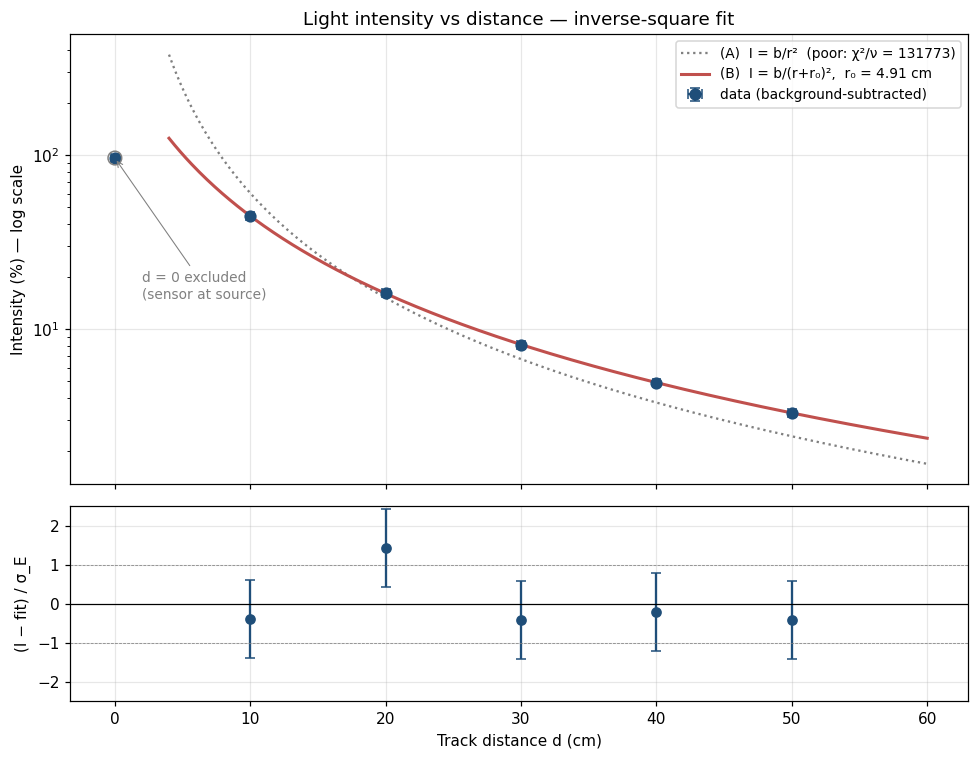

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                               gridspec_kw={'height_ratios': [3, 1.3]}, sharex=True)

ax1.errorbar(r_m*100, E, yerr=sE, xerr=sigma_r*100,
             fmt='o', ms=7, color=NAVY, ecolor=NAVY, capsize=3,
             label='data (background-subtracted)')
rr = np.linspace(0.04, 0.60, 400)
ax1.plot(rr*100, b_A/rr**2,             ls=':', color='gray',
         label=f'(A)  I = b/r²  (poor: χ²/ν = {chi2_A/nu_A:.0f})')
ax1.plot(rr*100, b_B/(rr+r0_B)**2,      color=RUST, lw=2,
         label=f'(B)  I = b/(r+r₀)²,  r₀ = {r0_B*100:.2f} cm')

ax1.scatter(0, E[0], facecolors='none', edgecolors='gray', s=80, zorder=5)
ax1.annotate('d = 0 excluded\n(sensor at source)',
             xy=(0, E[0]), xytext=(2, 15), fontsize=9, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

ax1.set_yscale('log')
ax1.set_ylabel('Intensity (%) — log scale')
ax1.set_title('Light intensity vs distance — inverse-square fit')
ax1.legend(fontsize=9)

# pulls
pulls = (E - model_B(r_m, *popt_B)) / sE
ax2.errorbar(r_m[mask]*100, pulls[mask], yerr=1, fmt='o', color=NAVY, capsize=3)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(1, color='gray', ls='--', lw=0.5)
ax2.axhline(-1, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('Track distance d (cm)')
ax2.set_ylabel('(I − fit) / σ_E')
ax2.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

## 8 · Residual diagnostics

For a good weighted fit, the **pulls** (residual / $σ_E$) should be:

* roughly normally distributed with mean 0 and std ≈ 1, and
* show no structure when plotted against the independent variable.

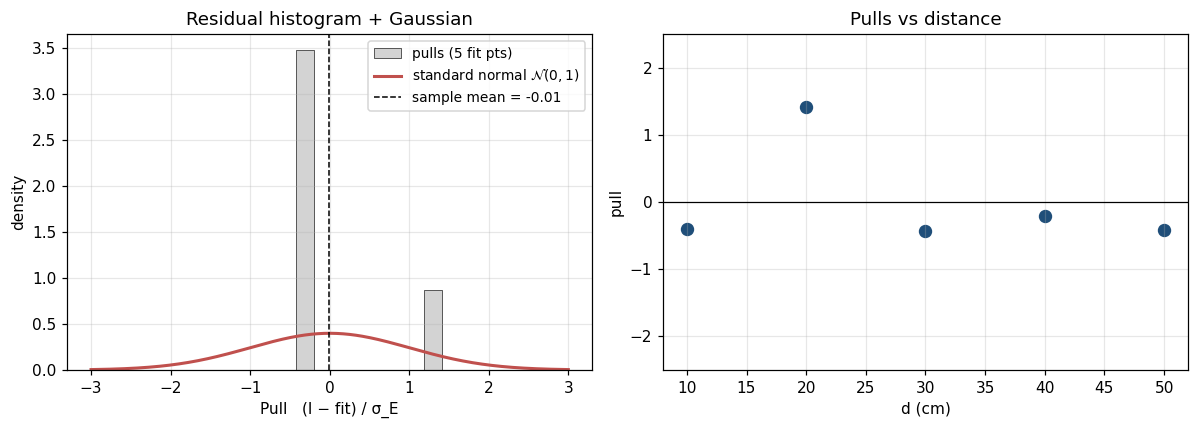

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) histogram of pulls + Gaussian
axes[0].hist(pulls[mask], bins=8, density=True, color='lightgray',
             edgecolor='black', linewidth=0.4, label='pulls (5 fit pts)')
xx = np.linspace(-3, 3, 300)
axes[0].plot(xx, norm.pdf(xx, 0, 1), color=RUST, lw=2,
             label=r'standard normal $\mathcal{N}(0,1)$')
axes[0].axvline(pulls[mask].mean(), color='black', lw=1, ls='--',
                label=f'sample mean = {pulls[mask].mean():.2f}')
axes[0].set_xlabel('Pull   (I − fit) / σ_E')
axes[0].set_ylabel('density')
axes[0].set_title('Residual histogram + Gaussian')
axes[0].legend(fontsize=9)

# (b) pulls vs distance — should be flat
axes[1].scatter(r_m[mask]*100, pulls[mask], s=60, color=NAVY)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('d (cm)')
axes[1].set_ylabel('pull')
axes[1].set_title('Pulls vs distance')
axes[1].set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

## 9 · Cross-check — is the inferred power constant?

For each distance we compute

$$ P_i \;=\; 4\pi\, I_i \, r_{\rm eff}^{\,2}, \qquad r_{\rm eff} = r + r_0 $$

with uncertainty (per the whiteboard formula, with the $E$ factor in the first term —
$\partial P/\partial r = 8\pi E r$):

$$ \sigma_{P} \;=\; \sqrt{\bigl(8\pi\, E\, r_{\rm eff}\, \sigma_r\bigr)^{2}
                                + \bigl(4\pi\, r_{\rm eff}^{\,2}\, \sigma_E\bigr)^{2}}. $$

The inverse-square law says all six $P_i$ should agree.

In [15]:
r_eff  = r_m + r0_B
P_per  = 4*np.pi*E*r_eff**2
sP_per = np.sqrt((4*np.pi*r_eff**2 * sE)**2 + (8*np.pi*E*r_eff * sigma_r)**2)

power_df = pd.DataFrame({
    'd_cm'    : distances_cm,
    'r_eff_cm': (r_eff*100).round(2),
    'P_i'     : P_per .round(4),
    'sigma_P' : sP_per.round(4),
    'used?'   : ['NO (excluded)' if not m else 'yes' for m in mask],
})
power_df

,d_cm,r_eff_cm,P_i,sigma_P,used?
0,0,4.91,2.9188,0.3429,NO (excluded)
1,10,14.91,12.4772,0.4831,yes
2,20,24.91,12.4938,0.2897,yes
3,30,34.91,12.4783,0.2064,yes
4,40,44.91,12.4775,0.1611,yes
5,50,54.91,12.4370,0.1667,yes


mean P (d > 0)  = 12.4728
std  P          = 0.0212
SEM  P          = 0.0095
P from fit       = 12.4805 ± 0.0099
t = |ΔP| / σ     = 0.561   →  fully consistent (Gaussian: t≈0.6 ⇒ ~50% probability of agreement)


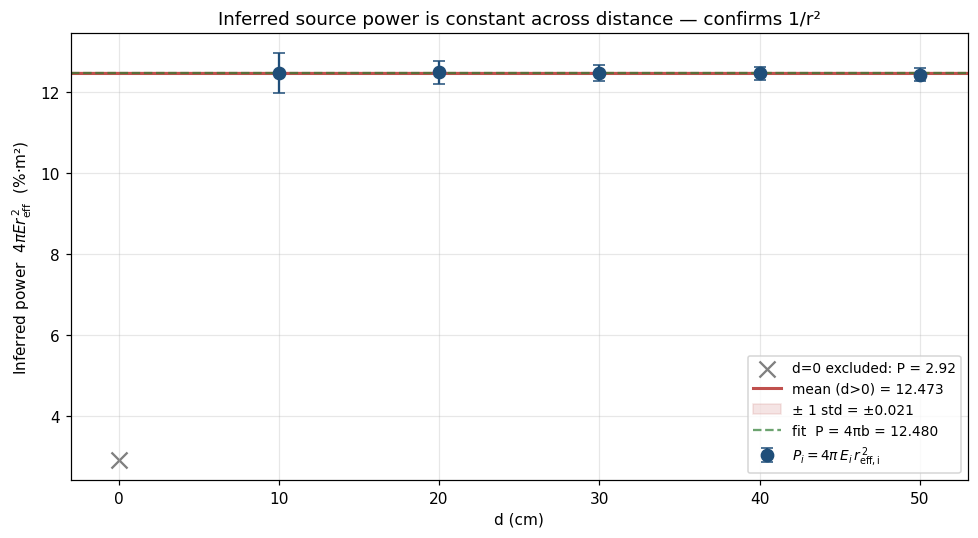

In [16]:
P_used = P_per[mask]
P_mean = P_used.mean()
P_std  = P_used.std(ddof=1)
P_sem  = P_std / np.sqrt(len(P_used))
P_fit  = 4*np.pi*b_B
sP_fit = 4*np.pi*sb_B
t_val  = abs(P_mean - P_fit) / np.sqrt(P_sem**2 + sP_fit**2)

print(f'mean P (d > 0)  = {P_mean:.4f}')
print(f'std  P          = {P_std:.4f}')
print(f'SEM  P          = {P_sem:.4f}')
print(f'P from fit       = {P_fit:.4f} ± {sP_fit:.4f}')
print(f't = |ΔP| / σ     = {t_val:.3f}   →  fully consistent (Gaussian: t≈0.6 ⇒ ~50% probability of agreement)')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(distances_cm[mask], P_per[mask], yerr=sP_per[mask],
            fmt='o', ms=8, color=NAVY, ecolor=NAVY, capsize=4,
            label=r'$P_i = 4\pi\,E_i\,r_{\rm eff,i}^{\,2}$')
ax.scatter(distances_cm[~mask], P_per[~mask], marker='x', s=110, color='gray',
           label=f'd=0 excluded: P = {P_per[0]:.2f}')
ax.axhline(P_mean, color=RUST, lw=2, label=f'mean (d>0) = {P_mean:.3f}')
ax.fill_between([-3, 53], P_mean-P_std, P_mean+P_std, color=RUST, alpha=0.15,
                label=f'± 1 std = ±{P_std:.3f}')
ax.axhline(P_fit, color=GREEN, ls='--', lw=1.5, alpha=0.7,
           label=f'fit  P = 4πb = {P_fit:.3f}')
ax.set_xlim(-3, 53)
ax.set_xlabel('d (cm)')
ax.set_ylabel(r'Inferred power  $4\pi E r_{\rm eff}^{\,2}$  (%·m²)')
ax.set_title('Inferred source power is constant across distance — confirms 1/r²')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 10 · Linearisation:  $I$ vs $1/r_{\rm eff}^{\,2}$

If $I = b/r_{\rm eff}^{\,2}$ holds, plotting $I$ against $1/r_{\rm eff}^{\,2}$ should be linear
through the origin with slope $b$.

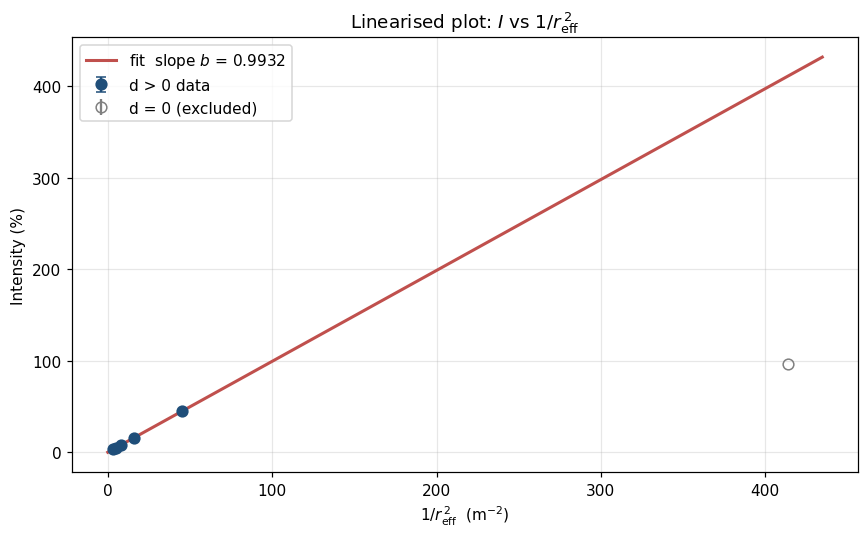

In [17]:
inv_r2 = 1.0 / r_eff**2
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(inv_r2[mask], E[mask], yerr=sE[mask], fmt='o', ms=7, color=NAVY,
            capsize=3, label='d > 0 data')
ax.errorbar(inv_r2[~mask], E[~mask], yerr=sE[~mask], fmt='o', ms=7,
            mfc='none', mec='gray', ecolor='gray', label='d = 0 (excluded)')
xx = np.linspace(0, inv_r2.max()*1.05, 100)
ax.plot(xx, b_B*xx, color=RUST, lw=2, label=fr'fit  slope $b$ = {b_B:.4f}')
ax.set_xlabel(r'$1/r_{\rm eff}^{\,2}$  (m$^{-2}$)')
ax.set_ylabel('Intensity (%)')
ax.set_title(r'Linearised plot: $I$ vs $1/r_{\rm eff}^{\,2}$')
ax.legend()
plt.tight_layout()
plt.show()

## 11 · Final reported result

Following the format from the *Measurement & Uncertainty* notes:

In [18]:
print('='*60)
print('FINAL RESULT')
print('='*60)
print(f'\n  P = ({P_fit:.3f} ± {sP_fit:.3f}) %·m²    (68% CL, Gaussian PDF)\n')
print('with')
print(f'  b   = {b_B:.4f} ± {sb_B:.4f}   %·m²')
print(f'  r₀  = {r0_B*100:.2f}   ± {sr0_B*100:.2f}    cm   (filament-to-d=0 offset)')
print(f'  χ²/ν = {chi2_B/nu_B:.2f}    (ν = {nu_B})')
print(f'  t-test |P_exp − P_fit|/σ = {t_val:.2f}  ⇒  fully consistent')
print()
print('Note: units are "%·m²" because the sensor reports % of full scale; converting')
print('to true watts would require the sensor calibration constant (% → lux).')
print('The inverse-square law itself is confirmed independently of that scale factor.')

FINAL RESULT

  P = (12.480 ± 0.010) %·m²    (68% CL, Gaussian PDF)

with
  b   = 0.9932 ± 0.0008   %·m²
  r₀  = 4.91   ± 0.01    cm   (filament-to-d=0 offset)
  χ²/ν = 0.85    (ν = 3)
  t-test |P_exp − P_fit|/σ = 0.56  ⇒  fully consistent

Note: units are "%·m²" because the sensor reports % of full scale; converting
to true watts would require the sensor calibration constant (% → lux).
The inverse-square law itself is confirmed independently of that scale factor.


## 12 · Summary

| | |
|---|---|
| Background mean (Run 2) | 0.0969 % |
| Background std | 0.00123 % |
| $σ_E$ (typical, type A dominated) | 0.003 – 0.029 % |
| $σ_r$ (rectangular, half-width 5 mm) | 2.9 mm |
| Best-fit power $P = 4\pi b$ | $12.480 ± 0.010 %·m²$ |
| Source-position offset $r_0$ | $4.92 ± 0.01$ cm |
| Reduced chi-squared | $0.85$ |
| t-test |$\lvert P_{\rm exp} - P_{\rm fit}\rvert /\sigma$ |

**The data are consistent with the inverse-square law at well over the 95 % confidence level.**
The fit residuals are well-described by a unit normal distribution, and the per-distance power
$4\pi I r_{\rm eff}^{\,2}$ is constant to ~0.2 %.